# Characterising our 2:1 systems
Four initial 2:1 MMR structure diagram values saved (i.e. $\delta$ and $\Psi\cos(\psi))$ before we compute the time-evolved arrays - we calculate diagram values where $\Psi\sin(\psi))$ < 0.01. They are as follows:
- Initial read-in from system parameters.
- Rotation to the invariant plane which alters $\pomega$
- Time-averaged semi-major axis and period without rotation
- Both time-averaged values and rotation

In [1]:
import os
import sys
currdir = os.getcwd()
# basedir = lambda path: f'/home/sliu/{path}'
datadir = lambda file: f'{currdir}/data/{file}'
import numpy as np
import pandas as pd

sys.path.insert(0, currdir)
import functionalities.general as gen
import functionalities.mmrdiagram as mm
import functionalities.reboundfuncs as re

table = pd.read_csv(datadir('newestversion.csv'))
gjsimelem = np.array(['P', 'm', 'e', 'inc', 'pomega', 'l'])

## GJ 876 Step-by-Step Characterisation


In [2]:
gjdiagvals = np.zeros((4, 2))
gjconvert = (gen.convertd).copy()
gjconvert['m'] = 1/gen.MSME

gjdf = gen.validate(table[table.sysname == 'GJ 876'].copy(), \
                  index=True, convertdict=gjconvert)
gjdiagdf = gjdf.copy()
gjdiagvals[0] = mm.quickndirty(gjdiagdf, verbose=True, ilocs=(1,2))
# the subsequent dataframes can be derived from diagdf because it has pomega. 
gjdf.drop(columns=['Notes'])

Do we have Pstar? False 
 Do we have astar? False 
 Do we have pomega? True 
 Do we have lamda? True 

Period-calculated: delta is 1.5318447276469869 and Psi*cos(psi) is -1.7187556444963674.
a-calculated: delta is 1.5609044970651487 and Psi*cos(psi) is -1.7180924306689882.


,sysname,type,mstar,planet,order,P,a,m,e,pomega,l,Omega,omega,inc,M,T0,source
Unnamed: 0,,,,,,,,,,,,,,,,,
GJ-876_d,GJ 876,best-fit,0.33,d,1,0.005305,0.021021,0.000020,0.0350,2.094395,3.794346,0.0,NaN,0.989602,NaN,NaN,Moutou 2023
GJ-876_c,GJ 876,best-fit,0.33,c,2,0.082420,0.130874,0.000707,0.2570,0.880519,5.998697,0.0,NaN,0.989602,NaN,NaN,Moutou 2023
GJ-876_b,GJ 876,best-fit,0.33,b,3,0.167292,0.209805,0.002250,0.0296,0.727802,0.280649,0.0,NaN,0.989602,NaN,NaN,Moutou 2023
GJ-876_e,GJ 876,best-fit,0.33,e,4,0.338261,0.335500,0.000048,0.0545,4.188790,3.618068,0.0,NaN,0.989602,NaN,NaN,Moutou 2023


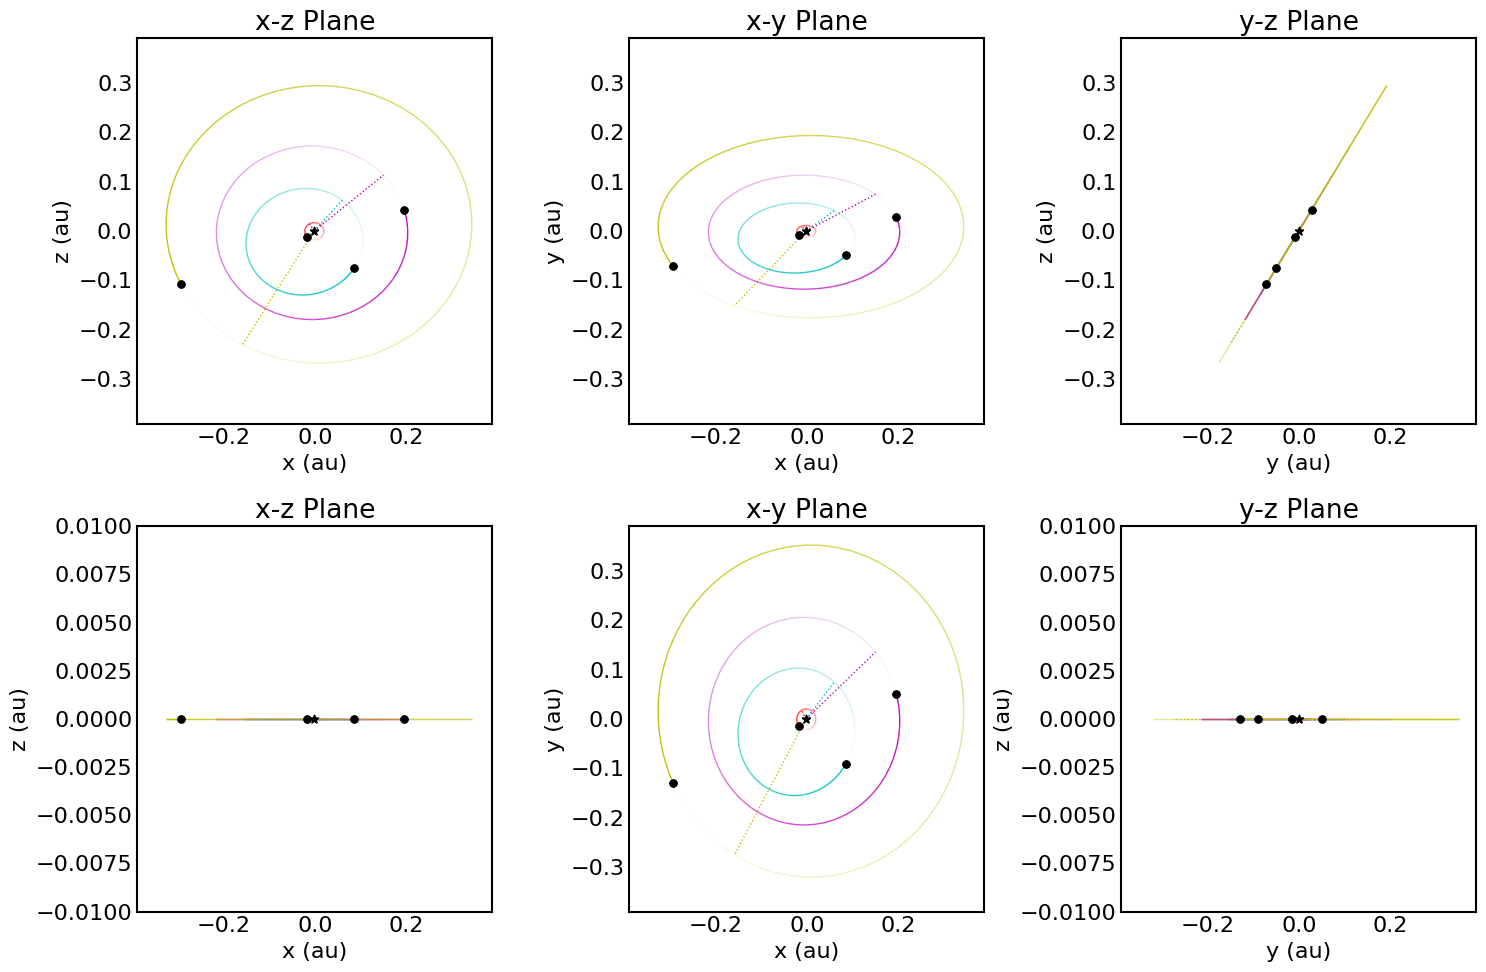

In [3]:
## Initialising the simulation
gjsim, gjhash = re.configSim(gjdiagdf, gjsimelem, verbose=False)
maxa = re.getbounds(gjsim)
boundd0 = {'x': maxa, 'y': maxa, 'z': maxa}
gjsim, gjrotated, gjrotcomp = re.rotatesimdf(gjsim, gjhash, gjdiagdf, plot=True, \
                                             boundd0=boundd0, boundd1=0.01)
gjdiagvals[1] = mm.quickndirty(gjrotated.copy(), ilocs=(1,2))
gjsim.integrator = 'whfast'
gjsim.dt = 0.05/365.25 # days to years

In [4]:
gjtime5000, gjintdict5000 = re.nbodyint_whfast(gjsim.copy(), re.saveorbs, list(gjhash.keys()), nsteps=10**5, tmax=5000)
gjtime20, gjintdict20 = re.nbodyint_whfast(gjsim.copy(), re.saveorbs, list(gjhash.keys()), tmax=20)
gjdiagvals[2] = mm.quickndirty(gen.timeAverage(gjintdict5000, df=gjdiagdf.copy()), ilocs=(1,2))
gjdiagvals[-1] = mm.quickndirty(gen.timeAverage(gjintdict5000, df=gjrotated.copy()), ilocs=(1,2), verbose=False)
print('For the five year intergration:')
gen.timeAverage(gjintdict20)
longdf = mm.mkdiagdf(gjtime5000, gjintdict5000, gjdf, check=True, order=(2,3))
# longdf.to_csv(datadir('GJ-876(5000).csv'))
shortdf = mm.mkdiagdf(gjtime20, gjintdict20, gjdf, check=True, order=(2,3))
# shortdf.to_csv(datadir('GJ-876(20).csv'))

 97%|█████████▋| 9739/10000 [00:04<00:00, 1964.01it/s]


For GJ-876_d: the time-averaged semi-major axis is 0.021021, the time-averaged period is 0.0053055.
For GJ-876_c: the time-averaged semi-major axis is 0.13139, the time-averaged period is 0.082818.
For GJ-876_b: the time-averaged semi-major axis is 0.21015, the time-averaged period is 0.16695.
For GJ-876_e: the time-averaged semi-major axis is 0.33913, the time-averaged period is 0.34224.
For GJ-876_d: the time-averaged semi-major axis is 0.021021, the time-averaged period is 0.0053055.
For GJ-876_c: the time-averaged semi-major axis is 0.13139, the time-averaged period is 0.082818.
For GJ-876_b: the time-averaged semi-major axis is 0.21015, the time-averaged period is 0.16695.
For GJ-876_e: the time-averaged semi-major axis is 0.33913, the time-averaged period is 0.34224.
For the five year intergration:
For GJ-876_d: the time-averaged semi-major axis is 0.021021, the time-averaged period is 0.0053055.
For GJ-876_c: the time-averaged semi-major axis is 0.13139, the time-averaged period

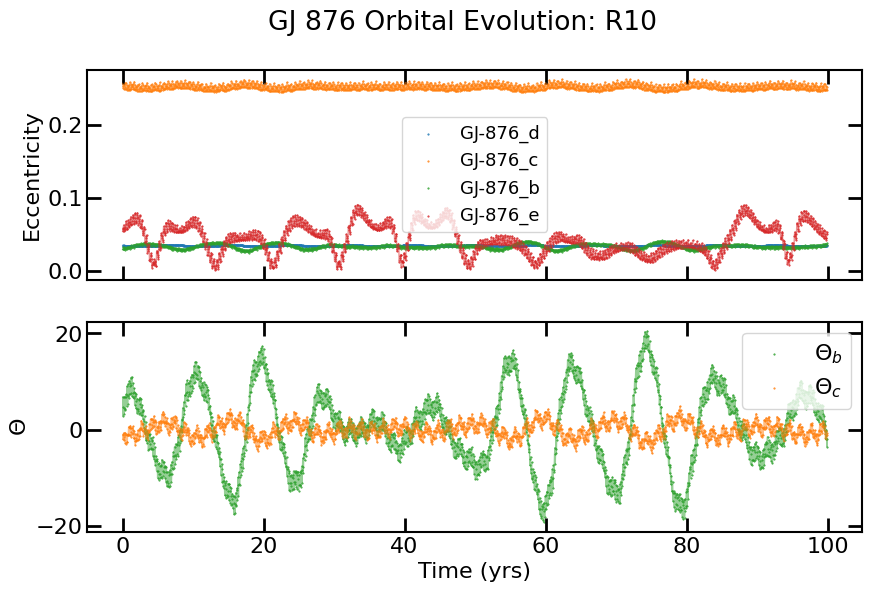

In [5]:
tm = gjtime5000 <= 100
fig, axs = gen.setupPlots((10, 6), row=2, col=1, sharex=True, logscale=0)

for pldex, pldict in gjintdict5000.items():
    axs[0].scatter(gjtime5000[tm], pldict['e'][tm], marker='.', s=1, label=pldex)
    axs[0].plot(gjtime5000[tm], pldict['e'][tm], lw=1, alpha=0.5)
axs[0].set_ylabel('Eccentricity')
axs[0].legend(fontsize=13)

_, thetac, thetab = gen.getResAngles(gjintdict5000['GJ-876_c'], gjintdict5000['GJ-876_b'])
axs[1].scatter(gjtime5000[tm], thetab[tm], color='tab:green', s=1, marker='.', label=r'$\Theta_b$')
axs[1].plot(gjtime5000[tm], thetab[tm], color='tab:green', lw=1, alpha=0.5)
axs[1].scatter(gjtime5000[tm], thetac[tm], color='tab:orange', s=1, marker='.', label=r'$\Theta_c$')
axs[1].plot(gjtime5000[tm], thetac[tm], color='tab:orange', lw=1, alpha=0.5)
axs[1].set_ylabel(r'$\Theta$')
axs[1].set_xlabel('Time (yrs)')
axs[1].legend()

fig.suptitle('GJ 876 Orbital Evolution: R10')
fig.show()
    

In [6]:
gjdiagvals

array([[ 1.53184473, -1.71875564],
       [ 1.53184473, -1.71875564],
       [ 1.52699005, -1.71388002],
       [ 1.52699005, -1.71388002]])

## Generalised Procedure


In [7]:
toi216pars = SysPars('TOI-216')
toi216df = gen.validate(table[table.sysname == 'TOI 216'].copy(), index=True, convertdict=gen.convertd)
belements = np.array(['P', 'm', 'e', 'inc', 'pomega', 'l'])
celements = np.array(['P', 'm', 'e', 'inc', 'pomega', 'Omega', 'l'])
toi216pars.simelements = np.array([belements, celements], dtype=object)
toi216pars.simplot = True
t16diagvals, t16tuple5000, t16tuple20 = toi216pars.syscharacter(toi216df)

NameError: name 'SysPars' is not defined

In [ ]:
def n22plot(time, toib, toic):
    '''
    Figure replication.
    '''
    tm = time <= 100

    
    fig, axs = gen.setupPlots((12, 8), row=2, col=2, sharex=True, logscale=0)
    axs[0, 0].plot(time[tm], toib['a'][tm], color='tab:red')
    axs[0, 0].plot(time[tm], toic['a'][tm], color='tab:blue')
    axs[0, 0].set_ylim(0, 0.35)
    axs[0, 0].set_ylabel('Semi-major axis (au)')
    axs[0, 1].plot(time[tm], toib['e'][tm], color='tab:red')
    axs[0, 1].plot(time[tm], toic['e'][tm], color='tab:blue')
    axs[0, 1].set_ylim(0, 0.2)
    axs[0, 1].set_ylabel('Eccentricity')

    deltatheta, thetab, thetac = gen.getResAngles(toib, toic)
    axs[1, 0].scatter(time[tm], thetab[tm], color='tab:red', s=1, label=r'$\theta_b$')
    axs[1, 0].scatter(time[tm], thetac[tm], color='tab:blue', s=1, label=r'$\theta_c$')
    axs[1, 0].set_ylabel('2:1 resonance angle (deg)')
    axs[1, 1].scatter(time[tm], -1*deltatheta[tm], color='black', s=1)
    axs[1, 1].set_ylim(-200, 200)
    axs[1, 1].set_ylabel(r'$\Delta$pomega')
    for ax in axs.flatten():
        ax.set_xlim(0, 100)
        ax.set_xlabel('Time (years)')
    fig.show()

n22plot(t16tuple5000[0], t16tuple5000[1]['TOI-216_b'], t16tuple5000[1]['TOI-216_c'])

In [ ]:
hd82pars = SysPars('HD-82943')
m = np.logical_and(table.sysname == 'HD 82943', table.type == 'coplanar inclined best-fit')
hd82df = gen.validate(table[m].copy(), index=True, convertdict=gen.convertd)
hd82pars.simelements = np.array(['P', 'm', 'e', 'inc', 'pomega', 'M'])
hd82pars.simplot = True
hd82pars.qndverbose = True
hd82pars.configverbose = True
hd82diagvals, hd82tuple5000, hd82tuple20 = hd82pars.syscharacter(hd82df)

In [ ]:
ylims = [(0.4, 1.4), (0, 0.6), (-100, 100), (-100, 100)]
ylabels = ['a (AU)', 'e', r'$\theta_1$ (deg)', r'$\theta_2$ (deg)']
def integrateplot(time, inner, outer, axs, ylims=ylims, ylabels=ylabels):
    '''
    '''
    axs[0].plot(time, inner['a'], lw=0.1)
    axs[0].plot(time, outer['a'], lw=0.1)
    axs[1].plot(time, inner['e'], lw=0.1)
    axs[1].plot(time, outer['e'], lw=0.1)

    _, innertheta, outertheta = gen.getResAngles(inner, outer)
    axs[2].plot(time, innertheta, color='tab:green', lw=0.1)
    axs[3].plot(time, outertheta, color='tab:green', lw=0.1)
    
    for i, ax in enumerate(axs):
        ax.set_xlim(0, 5000)
        ax.set_ylim(*ylims[i])
        ax.set_ylabel(ylabels[i])
    return axs

fig, axs = gen.setupPlots((8, 10), sharex=True, row=4, col=1, logscale=0)
hd82c, hd82d = hd82tuple5000[1]['HD-82943_inc_c'], hd82tuple5000[1]['HD-82943_inc_d']
axs = integrateplot(hd82tuple5000[0], hd82c, hd82d, axs)
fig.show()

In [ ]:
hd82df